In [ ]:
import warnings

# Suppress all DeprecationWarnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
print("All Deprecation warnings will now be suppressed.")

All Deprecation warnings will now be suppressed.


In [ ]:
import pandas as pd
import glob

path = "/content/*.csv"
files = glob.glob(path)

df_list = []

for file in files:
    df = pd.read_csv(file)
    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)
data.to_csv("cicids2017_cleaned.csv", index=False)

print(data.shape)

(1223054, 79)


In [ ]:
df.head(15)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3268,112740690,32,16,6448,1152,403,0,201.500000,204.724205,...,32.0,3.594286e+02,1.199802e+01,380.0,343.0,16100000.0,4.988048e+05,16400000.0,15400000.0,BENIGN
1,389,112740560,32,16,6448,5056,403,0,201.500000,204.724205,...,32.0,3.202857e+02,1.574499e+01,330.0,285.0,16100000.0,4.987937e+05,16400000.0,15400000.0,BENIGN
2,0,113757377,545,0,0,0,0,0,0.000000,0.000000,...,0.0,9.361829e+06,7.324646e+06,18900000.0,19.0,12200000.0,6.935824e+06,20800000.0,5504997.0,BENIGN
3,5355,100126,22,0,616,0,28,28,28.000000,0.000000,...,32.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN
4,0,54760,4,0,0,0,0,0,0.000000,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN
5,88,617,7,4,484,414,233,0,69.142857,111.967895,...,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN
6,1031,8,1,1,6,6,6,6,6.000000,0.000000,...,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN
7,88,881,9,4,656,3064,313,0,72.888889,136.153814,...,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN
8,88,1056,9,6,3134,3048,1552,0,348.222222,682.482560,...,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN
9,88,515,7,4,2812,2820,1397,0,401.714286,679.914876,...,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN


In [ ]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [ ]:
import pandas as pd
import numpy as np

# clean column names
data.columns = data.columns.str.strip()

# clean labels
data['Label'] = data['Label'].astype(str).str.strip()
data['Label'] = data['Label'].str.replace('Web Attack � Brute Force', 'Web Attack Brute Force')
data['Label'] = data['Label'].str.replace('Web Attack � XSS', 'Web Attack XSS')
data['Label'] = data['Label'].str.replace('Web Attack � Sql Injection', 'Web Attack Sql Injection')


# remove BENIGN
data = data[~data['Label'].str.upper().str.contains('BENIGN')].copy()

# remove inf/nan
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

# drop duplicates
data.drop_duplicates(inplace=True)


print("After cleaning:")
print(data['Label'].value_counts())

After cleaning:
Label
DoS Hulk                  115987
DDoS                       15471
FTP-Patator                 5931
DoS slowloris               5385
DoS Slowhttptest            5228
SSH-Patator                 1685
Web Attack Brute Force       687
PortScan                     102
Bot                            2
Name: count, dtype: int64


In [ ]:
top5 = data['Label'].value_counts().head(5).index
data = data[data['Label'].isin(top5)].copy()

print("Top 5 classes:")
print(data['Label'].value_counts())

Top 5 classes:
Label
DoS Hulk            115987
DDoS                 15471
FTP-Patator           5931
DoS slowloris         5385
DoS Slowhttptest      5228
Name: count, dtype: int64


In [ ]:
# drop useless columns
drop_cols = [c for c in ['Flow ID', 'Src IP', 'Source IP', 'Dst IP', 'Destination IP', 'Timestamp'] if c in data.columns]

X = data.drop(columns=drop_cols + ['Label'])
y = data['Label']

# keep numeric
X = X.select_dtypes(include=[np.number]).copy()

# handle inf/nan
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['DDoS' 'DoS Hulk' 'DoS Slowhttptest' 'DoS slowloris' 'FTP-Patator']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
train_df = X_train.copy()
train_df['Label'] = y_train

min_count = train_df['Label'].value_counts().min()

train_balanced = train_df.groupby('Label', group_keys=False).apply(
    lambda x: x.sample(min_count, random_state=42)
)

# FINAL train data
X_train_bal = train_balanced.drop(columns=['Label'])
y_train_bal = train_balanced['Label']

In [ ]:
print(train_balanced['Label'].value_counts())

Label
0    4182
1    4182
2    4182
3    4182
4    4182
Name: count, dtype: int64


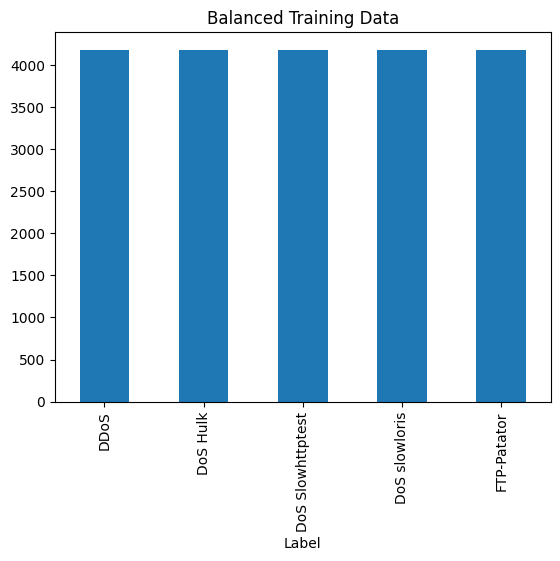

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

y_train_labels = pd.Series(y_train_bal).map(dict(enumerate(le.classes_)))

y_train_labels.value_counts().plot(kind='bar')

plt.title("Balanced Training Data")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt = DecisionTreeClassifier(max_depth=10, random_state=42)

# TRAIN on BALANCED
dt.fit(X_train_bal, y_train_bal)

# TEST on ORIGINAL TEST
y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9991554339380426
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3094
           1       1.00      1.00      1.00     23198
           2       0.99      0.99      0.99      1046
           3       0.99      0.99      0.99      1077
           4       1.00      1.00      1.00      1186

    accuracy                           1.00     29601
   macro avg       1.00      1.00      1.00     29601
weighted avg       1.00      1.00      1.00     29601



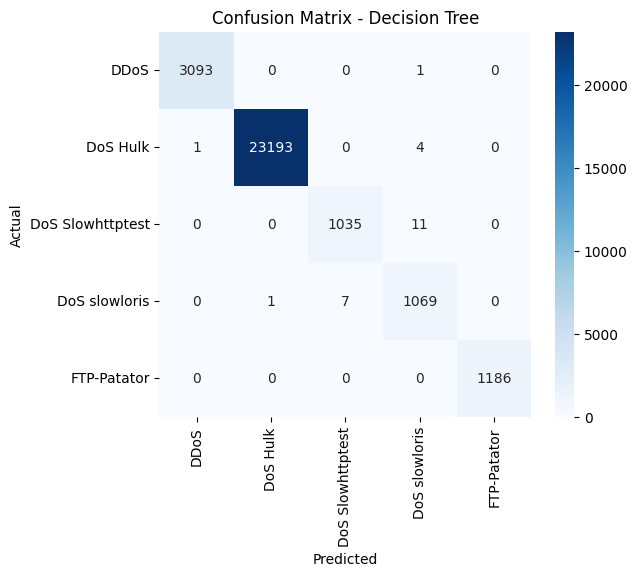

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Random Forest


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_bal, y_train_bal)

RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Accuracy: 0.9995270430053039

Classification Report:
                  precision    recall  f1-score   support

            DDoS       1.00      1.00      1.00      3094
        DoS Hulk       1.00      1.00      1.00     23198
DoS Slowhttptest       1.00      0.99      0.99      1046
   DoS slowloris       0.99      1.00      0.99      1077
     FTP-Patator       1.00      1.00      1.00      1186

        accuracy                           1.00     29601
       macro avg       1.00      1.00      1.00     29601
    weighted avg       1.00      1.00      1.00     29601



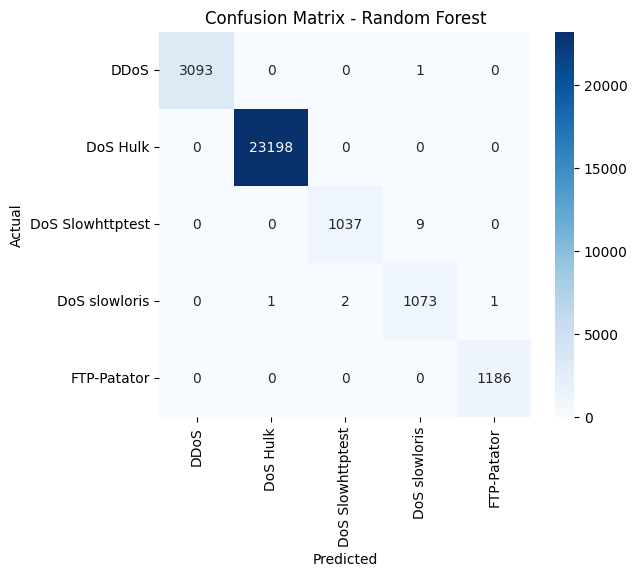

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

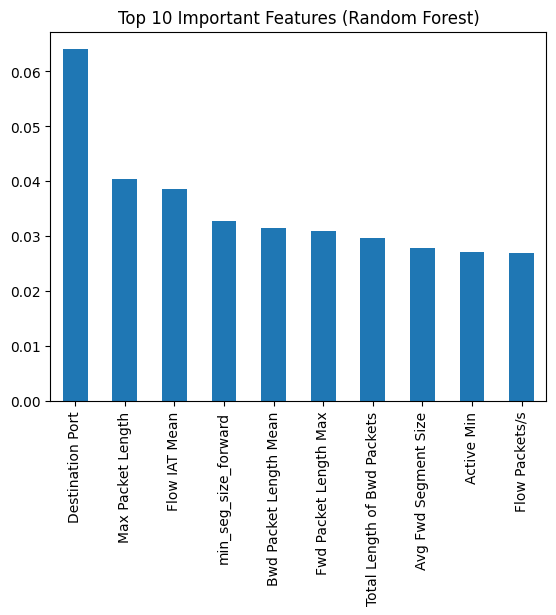

In [ ]:
import pandas as pd

importances = rf.feature_importances_
feat_names = X_train_bal.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')

plt.title("Top 10 Important Features (Random Forest)")
plt.show()

XGboost


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(X_train_bal, y_train_bal)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

Accuracy: 0.9993581297929124

Classification Report:
                  precision    recall  f1-score   support

            DDoS       1.00      1.00      1.00      3094
        DoS Hulk       1.00      1.00      1.00     23198
DoS Slowhttptest       1.00      0.99      0.99      1046
   DoS slowloris       0.99      1.00      0.99      1077
     FTP-Patator       1.00      1.00      1.00      1186

        accuracy                           1.00     29601
       macro avg       1.00      1.00      1.00     29601
    weighted avg       1.00      1.00      1.00     29601



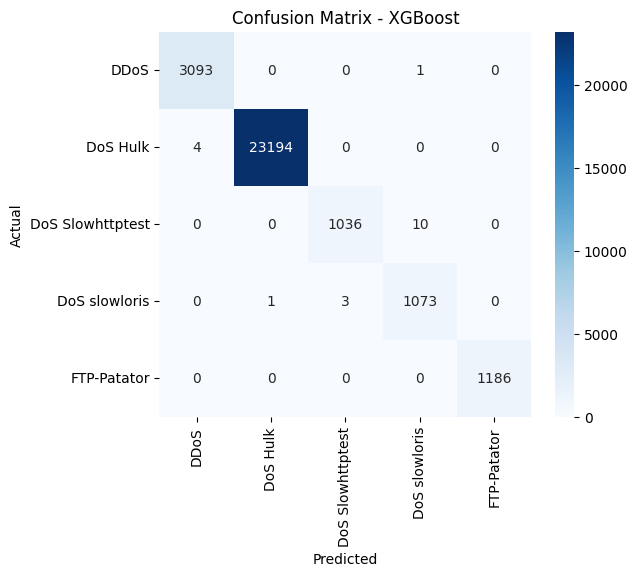

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, y_pred_xgb),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Comparison Table

In [ ]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

results = []

results.append([
    "Decision Tree",
    accuracy_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt, average='macro')
])

results.append([
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf, average='macro')
])

results.append([
    "XGBoost",
    accuracy_score(y_test, y_pred_xgb),
    f1_score(y_test, y_pred_xgb, average='macro')
])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])

print(results_df)

           Model  Accuracy  F1 Score
0  Decision Tree  0.999155  0.995965
1  Random Forest  0.999527  0.997528
2        XGBoost  0.999358  0.997182


In [ ]:
def generate_alert(predicted_attack):
    rules = get_matching_rules(predicted_attack)
    best_rule = get_best_rule(rules)

    print("\n===== ALERT SYSTEM OUTPUT =====")
    print("ML Prediction:", predicted_attack)

    if best_rule:
        risk = compute_risk(best_rule)

        print("Matched Rule:", best_rule["from"], "->", best_rule["to"])
        print("Confidence:", round(best_rule["confidence"], 3))
        print("Lift:", best_rule["lift"])
        print("Risk Score:", round(risk, 2))

        if risk > 80:
            print("ALERT LEVEL: CRITICAL ⚠️")
        elif risk > 60:
            print("ALERT LEVEL: HIGH ⚠️")
        else:
            print("ALERT LEVEL: MEDIUM")

        print("Next Likely Attack:", best_rule["to"])

    else:
        print("No rule matched.")

In [ ]:
predicted_label = le.inverse_transform([dt.predict(X_test.iloc[0].values.reshape(1, -1))[0]])[0]
print("Predicted Attack:", predicted_label)

Predicted Attack: DoS Hulk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
association_rules = [
    {"from": "Malware", "to": "DDoS", "confidence": 0.3333, "lift": 1.23},
    {"from": "Malware", "to": "Brute Force", "confidence": 0.3333, "lift": 1.15},
    {"from": "MITM Attack", "to": "Privilege Escalation", "confidence": 0.2609, "lift": 0.84},
    {"from": "XSS Attack", "to": "Port Scanning", "confidence": 0.25, "lift": 0.89},
    {"from": "Privilege Escalation", "to": "Brute Force", "confidence": 0.2258, "lift": 0.78},
    {"from": "SQL Injection", "to": "Brute Force", "confidence": 0.2143, "lift": 0.74},
    {"from": "Port Scanning", "to": "Ransomware", "confidence": 0.2143, "lift": 0.74},
    {"from": "Ransomware", "to": "Botnet", "confidence": 0.2143, "lift": 0.86},
    {"from": "SQL Injection", "to": "Privilege Escalation", "confidence": 0.2143, "lift": 0.69},
    {"from": "XSS Attack", "to": "Privilege Escalation", "confidence": 0.2083, "lift": 0.67},
    {"from": "Privilege Escalation", "to": "MITM Attack", "confidence": 0.1935, "lift": 0.84},
    {"from": "Port Scanning", "to": "Brute Force", "confidence": 0.1786, "lift": 0.62},
    {"from": "SQL Injection", "to": "XSS Attack", "confidence": 0.1786, "lift": 0.74},
    {"from": "SQL Injection", "to": "Ransomware", "confidence": 0.1786, "lift": 0.64},
    {"from": "Ransomware", "to": "Privilege Escalation", "confidence": 0.1786, "lift": 0.58},
    {"from": "Brute Force", "to": "Port Scanning", "confidence": 0.1724, "lift": 0.62},
    {"from": "Privilege Escalation", "to": "DDoS", "confidence": 0.1613, "lift": 0.60}
]

In [ ]:
def get_best_rule(predicted_attack):
    forward = [r for r in association_rules if r["from"] == predicted_attack]
    backward = [r for r in association_rules if r["to"] == predicted_attack]

    if forward:
        return max(forward, key=lambda r: r["confidence"] * r["lift"]), "forward"

    if backward:
        return max(backward, key=lambda r: r["confidence"] * r["lift"]), "backward"

    return None, None

In [ ]:
def get_severity(attack):
    severity = {
        "Brute Force": 3,
        "Privilege Escalation": 5,
        "DDoS": 5,
        "Malware": 4,
        "SQL Injection": 4,
        "Ransomware": 5,
        "Port Scanning": 2,
        "XSS Attack": 3,
        "MITM Attack": 4,
        "Botnet": 5
    }
    return severity.get(attack, 2)


def compute_risk(rule):
    return (
        rule["confidence"] * 50 +
        rule["lift"] * 20 +
        get_severity(rule["to"]) * 10
    )

In [ ]:
def generate_alert(predicted_attack):
    rule, direction = get_best_rule(predicted_attack)

    print("\n===== HYBRID IDS OUTPUT =====") # Fixed: Added closing double quote
    print("ML Prediction:", predicted_attack)

    if rule:
        risk = compute_risk(rule)

        if direction == "forward":
            print("Pattern: Current → Next Attack")
            print(f"{rule['from']} → {rule['to']}")
            print("Next Likely Attack:", rule["to"])
        else:
            print("Pattern: Previous → Current Attack")
            print(f"{rule['from']} → {rule['to']}")
            print("Possible Previous Attack:", rule["from"])

        if direction == "backward":
            print("⚠️ System may already be compromised before this attack")

        print("Confidence:", round(rule["confidence"], 3))
        print("Lift:", rule["lift"])
        print("Risk Score:", round(risk, 2))

        if risk > 80:
            print("ALERT: CRITICAL ⚠️")
        elif risk > 60:
            print("ALERT: HIGH ⚠️")
        else:
            print("ALERT: MEDIUM")

    else:
        print("No rule matched.")

In [ ]:
print(le.classes_)

['DDoS' 'DoS Hulk' 'DoS Slowhttptest' 'DoS slowloris' 'FTP-Patator']


In [ ]:
label_map = {
    "FTP-Patator": "Brute Force",
    "SSH-Patator": "Brute Force",   # if exists
    "PortScan": "Port Scanning",
    "DoS Hulk": "DDoS",
    "DoS GoldenEye": "DDoS",
    "DDoS": "DDoS"
}

In [ ]:
# Take the first sample from X_test for demonstration purposes
sample = X_test.iloc[0].values.reshape(1, -1)
pred_num = rf.predict(sample)[0]

pred_label = le.inverse_transform([pred_num])[0]

mapped_label = label_map.get(pred_label, pred_label)

print("Original Prediction:", pred_label)
print("Mapped Prediction:", mapped_label)

Original Prediction: DoS Hulk
Mapped Prediction: DDoS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Example (replace with your real model)
# Use RandomForestClassifier (rf) as an example model
predicted_attack_index = rf.predict(X_test.iloc[[0]])[0]
predicted_attack_label = le.inverse_transform([predicted_attack_index])[0]

generate_alert(mapped_label)


===== HYBRID IDS OUTPUT =====
ML Prediction: DDoS
Pattern: Previous → Current Attack
Malware → DDoS
Possible Previous Attack: Malware
⚠️ System may already be compromised before this attack
Confidence: 0.333
Lift: 1.23
Risk Score: 91.27
ALERT: CRITICAL ⚠️


In [ ]:
import numpy as np

for i in range(5):
    print(f"\n--- Incoming Traffic {i} ---")

    idx = np.random.randint(0, len(X_test))
    sample = X_test.iloc[idx].values.reshape(1, -1)

    pred_num = rf.predict(sample)[0]
    pred_label = le.inverse_transform([pred_num])[0]

    mapped_label = label_map.get(pred_label, pred_label)

    generate_alert(mapped_label)


--- Incoming Traffic 0 ---

===== HYBRID IDS OUTPUT =====
ML Prediction: DDoS
Pattern: Previous → Current Attack
Malware → DDoS
Possible Previous Attack: Malware
⚠️ System may already be compromised before this attack
Confidence: 0.333
Lift: 1.23
Risk Score: 91.27
ALERT: CRITICAL ⚠️

--- Incoming Traffic 1 ---

===== HYBRID IDS OUTPUT =====
ML Prediction: DDoS
Pattern: Previous → Current Attack
Malware → DDoS
Possible Previous Attack: Malware
⚠️ System may already be compromised before this attack
Confidence: 0.333
Lift: 1.23
Risk Score: 91.27
ALERT: CRITICAL ⚠️

--- Incoming Traffic 2 ---

===== HYBRID IDS OUTPUT =====
ML Prediction: DDoS
Pattern: Previous → Current Attack
Malware → DDoS
Possible Previous Attack: Malware
⚠️ System may already be compromised before this attack
Confidence: 0.333
Lift: 1.23
Risk Score: 91.27
ALERT: CRITICAL ⚠️

--- Incoming Traffic 3 ---

===== HYBRID IDS OUTPUT =====
ML Prediction: DDoS
Pattern: Previous → Current Attack
Malware → DDoS
Possible Previou

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



===== HYBRID IDS OUTPUT =====
ML Prediction: DDoS
Pattern: Previous → Current Attack
Malware → DDoS
Possible Previous Attack: Malware
⚠️ System may already be compromised before this attack
Confidence: 0.333
Lift: 1.23
Risk Score: 91.27
ALERT: CRITICAL ⚠️


In [ ]:
unique_indices = np.random.choice(len(X_test), size=5, replace=False)

for idx in unique_indices:
    sample = X_test.iloc[idx].values.reshape(1, -1)

    pred_num = rf.predict(sample)[0]
    pred_label = le.inverse_transform([pred_num])[0]

    print(pred_label)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


DoS Hulk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


DoS Hulk
DoS slowloris


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


DoS Hulk
DoS Hulk


In [ ]:
print(pd.Series(y_test).value_counts())

1    23198
0     3094
4     1186
3     1077
2     1046
Name: count, dtype: int64


In [ ]:
!pip install networkx matplotlib

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
def build_attack_graph():
    G = nx.DiGraph()

    for rule in association_rules:
        G.add_edge(
            rule["from"],
            rule["to"],
            weight=rule["confidence"]
        )

    return G

In [ ]:
def draw_graph(G):
    plt.figure(figsize=(10, 7))

    pos = nx.spring_layout(G, seed=42)

    nx.draw(G, pos,
            with_labels=True,
            node_size=2000,
            font_size=10)

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title("Attack Chain Graph")
    plt.show()

In [ ]:
def draw_graph_with_highlight(G, current_attack):
    plt.figure(figsize=(10, 7))

    pos = nx.spring_layout(G, seed=42)

    # node colors
    node_colors = []
    for node in G.nodes():
        if node == current_attack:
            node_colors.append("red")   # current attack
        else:
            node_colors.append("lightblue")

    nx.draw(G, pos,
            with_labels=True,
            node_color=node_colors,
            node_size=2000,
            font_size=10)

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title(f"Attack Graph (Current: {current_attack})")
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Current Attack: DDoS


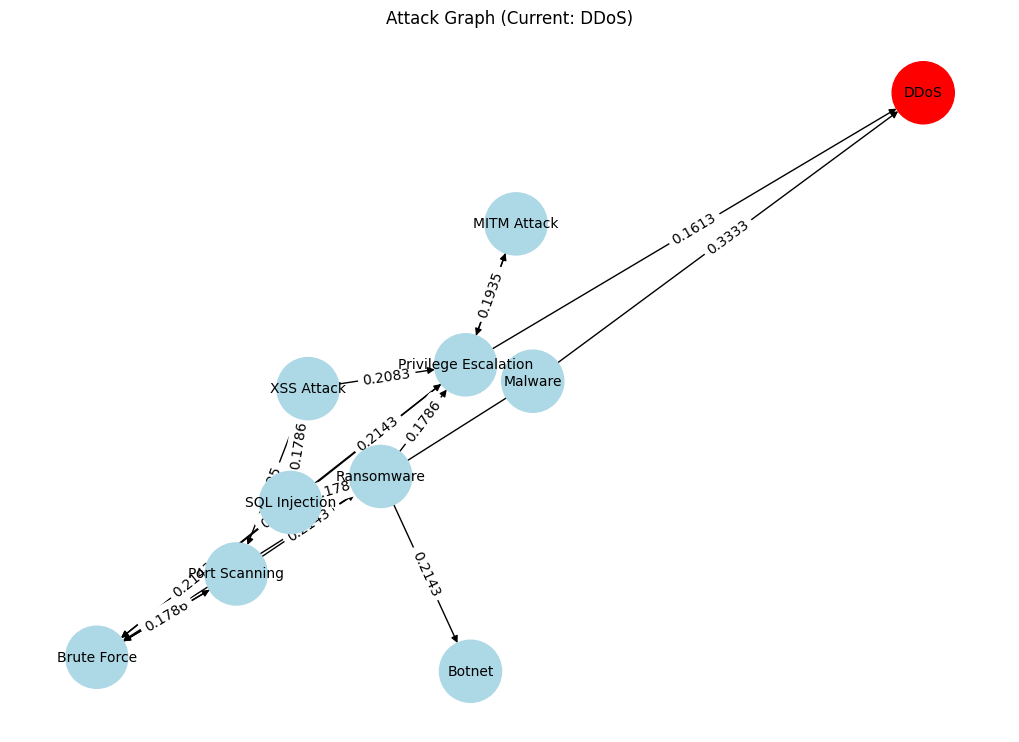

In [ ]:
# build graph once
G = build_attack_graph()

# sample prediction
sample = X_test.iloc[0].values.reshape(1, -1)

pred_num = rf.predict(sample)[0]
pred_label = le.inverse_transform([pred_num])[0]
mapped_label = label_map.get(pred_label, pred_label)

print("Current Attack:", mapped_label)

# show graph
draw_graph_with_highlight(G, mapped_label)


In [ ]:
def draw_local_graph(G, current_attack):
    neighbors = list(G.successors(current_attack)) + list(G.predecessors(current_attack))
    sub_nodes = neighbors + [current_attack]

    subG = G.subgraph(sub_nodes)

    draw_graph_with_highlight(subG, current_attack)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import time

In [ ]:
def build_attack_graph():
    G = nx.DiGraph()

    for rule in association_rules:
        G.add_edge(
            rule["from"],
            rule["to"],
            weight=round(rule["confidence"], 2)
        )

    return G

G = build_attack_graph()

In [ ]:
def draw_graph_live(G, current_attack):
    plt.figure(figsize=(8, 6))

    pos = nx.spring_layout(G, seed=42)

    node_colors = []
    for node in G.nodes():
        if node == current_attack:
            node_colors.append("red")
        else:
            node_colors.append("lightblue")

    nx.draw(G, pos,
            with_labels=True,
            node_color=node_colors,
            node_size=1800,
            font_size=9)

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title(f"Current Attack: {current_attack}")
    plt.show()

In [ ]:
def process_stream(index):
    sample = X_test.iloc[index].values.reshape(1, -1)

    # ML prediction
    pred_num = rf.predict(sample)[0]
    pred_label = le.inverse_transform([pred_num])[0]

    # mapping
    mapped_label = label_map.get(pred_label, pred_label)

    print("\n==============================")
    print(f"Incoming Traffic #{index}")
    print("Original Prediction:", pred_label)
    print("Mapped Attack:", mapped_label)

    # Alert
    generate_alert(mapped_label)
    print("Recommended Action: Investigate system / isolate host")

    # Graph
    draw_graph_live(G, mapped_label)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Incoming Traffic #0
Original Prediction: DoS Hulk
Mapped Attack: DDoS

===== HYBRID IDS OUTPUT =====
ML Prediction: DDoS
Pattern: Previous → Current Attack
Malware → DDoS
Possible Previous Attack: Malware
⚠️ System may already be compromised before this attack
Confidence: 0.333
Lift: 1.23
Risk Score: 91.27
ALERT: CRITICAL ⚠️
Recommended Action: Investigate system / isolate host


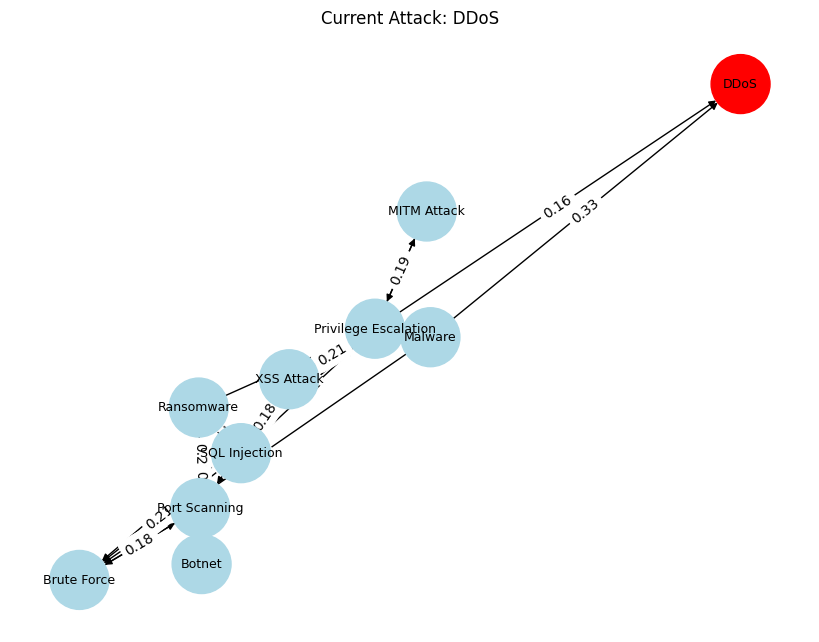

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Incoming Traffic #1
Original Prediction: DoS Hulk
Mapped Attack: DDoS

===== HYBRID IDS OUTPUT =====
ML Prediction: DDoS
Pattern: Previous → Current Attack
Malware → DDoS
Possible Previous Attack: Malware
⚠️ System may already be compromised before this attack
Confidence: 0.333
Lift: 1.23
Risk Score: 91.27
ALERT: CRITICAL ⚠️
Recommended Action: Investigate system / isolate host


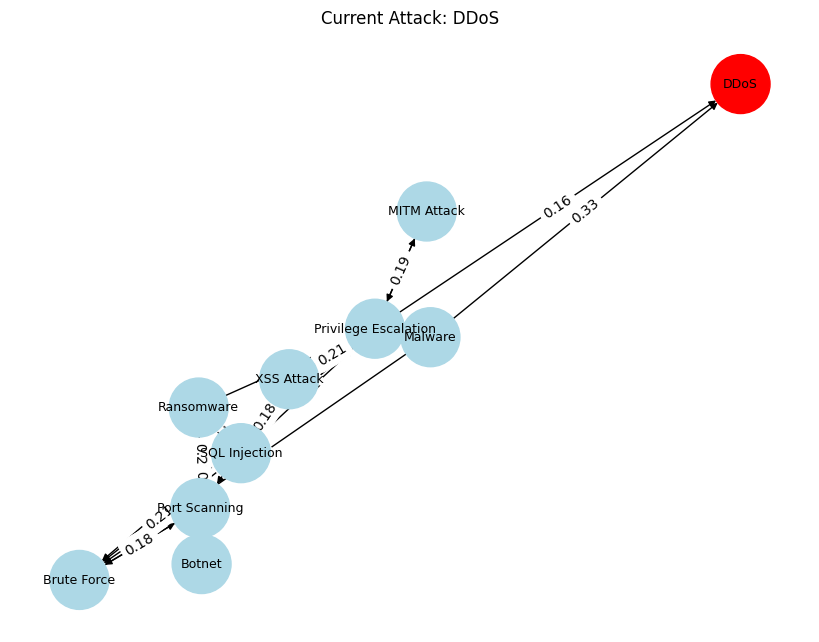

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Incoming Traffic #2
Original Prediction: DoS Hulk
Mapped Attack: DDoS

===== HYBRID IDS OUTPUT =====
ML Prediction: DDoS
Pattern: Previous → Current Attack
Malware → DDoS
Possible Previous Attack: Malware
⚠️ System may already be compromised before this attack
Confidence: 0.333
Lift: 1.23
Risk Score: 91.27
ALERT: CRITICAL ⚠️
Recommended Action: Investigate system / isolate host


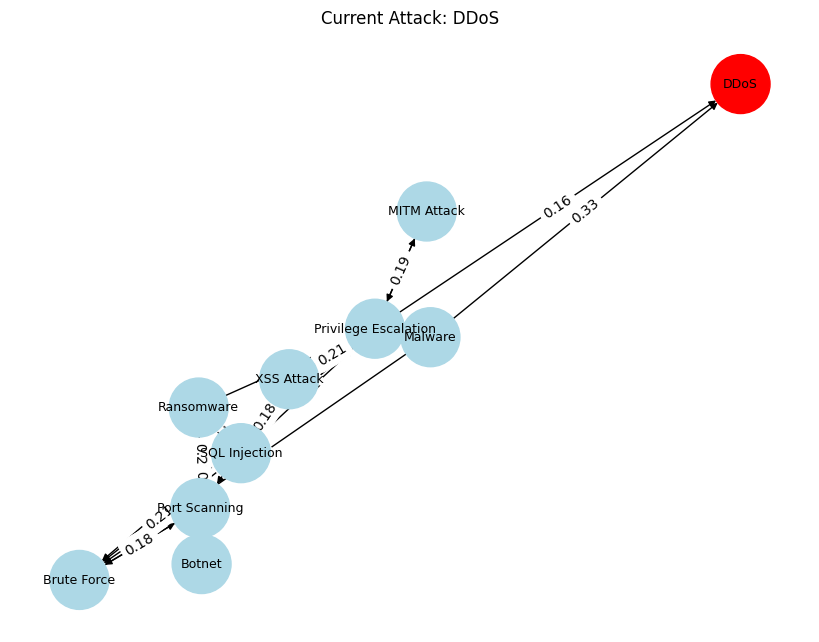

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Incoming Traffic #3
Original Prediction: DoS Hulk
Mapped Attack: DDoS

===== HYBRID IDS OUTPUT =====
ML Prediction: DDoS
Pattern: Previous → Current Attack
Malware → DDoS
Possible Previous Attack: Malware
⚠️ System may already be compromised before this attack
Confidence: 0.333
Lift: 1.23
Risk Score: 91.27
ALERT: CRITICAL ⚠️
Recommended Action: Investigate system / isolate host


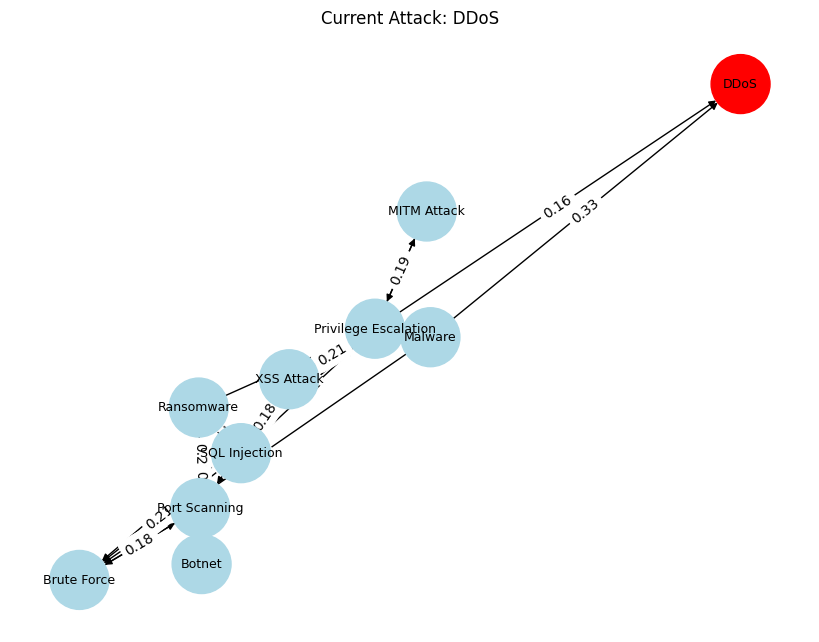

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Incoming Traffic #4
Original Prediction: DoS Hulk
Mapped Attack: DDoS

===== HYBRID IDS OUTPUT =====
ML Prediction: DDoS
Pattern: Previous → Current Attack
Malware → DDoS
Possible Previous Attack: Malware
⚠️ System may already be compromised before this attack
Confidence: 0.333
Lift: 1.23
Risk Score: 91.27
ALERT: CRITICAL ⚠️
Recommended Action: Investigate system / isolate host


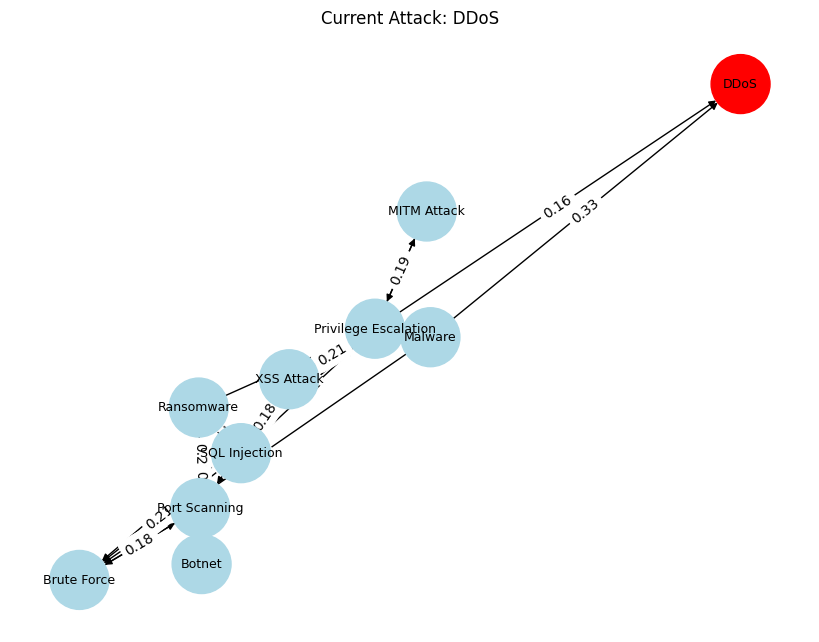

In [ ]:
for i in range(5):   # 5 events demo
    process_stream(i)
    time.sleep(2)   # delay for real-time feel